     0    1    2     3     4     5    6    7    8    9  ...   55   56   57  \
0  0.0  0.0  5.0  13.0   9.0   1.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
1  0.0  0.0  0.0  12.0  13.0   5.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
2  0.0  0.0  0.0   4.0  15.0  12.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   
3  0.0  0.0  7.0  15.0  13.0   1.0  0.0  0.0  0.0  8.0  ...  0.0  0.0  0.0   
4  0.0  0.0  0.0   1.0  11.0   0.0  0.0  0.0  0.0  0.0  ...  0.0  0.0  0.0   

    58    59    60    61   62   63  label  
0  6.0  13.0  10.0   0.0  0.0  0.0      0  
1  0.0  11.0  16.0  10.0  0.0  0.0      1  
2  0.0   3.0  11.0  16.0  9.0  0.0      2  
3  7.0  13.0  13.0   9.0  0.0  0.0      3  
4  0.0   2.0  16.0   4.0  0.0  0.0      4  

[5 rows x 65 columns]


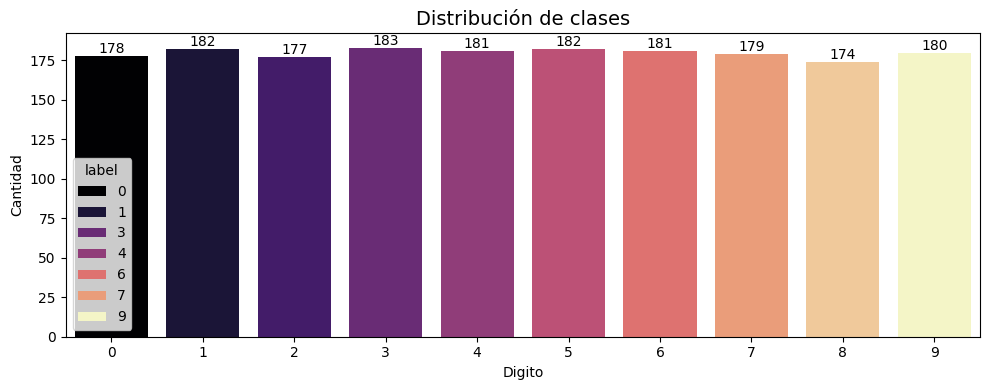

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2288 - loss: 2.2900 - val_accuracy: 0.3760 - val_loss: 2.2692
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4764 - loss: 2.2289 - val_accuracy: 0.5933 - val_loss: 2.1664
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7058 - loss: 2.0553 - val_accuracy: 0.6462 - val_loss: 1.9207
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7684 - loss: 1.7191 - val_accuracy: 0.8078 - val_loss: 1.5077
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8359 - loss: 1.2854 - val_accuracy: 0.8412 - val_loss: 1.1227
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8693 - loss: 0.9422 - val_accuracy: 0.8412 - val_loss: 0.8447
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8776 - loss: 0.7277 - val_accuracy: 0.8719 - val_loss: 0.6776
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8846 - loss: 0.6020 - val_accuracy: 0.8830 - val_loss:

In [ ]:
#Nombre Estudiante: Catalina Andrea Aguilera Letelier
#Generación: RTD-25-01-05-0019-1

#2 Implementación del modelo CNN para reconocimiento de imágenes
#Utilizando el dataset digitos_mnist_simple.csv, construye un modelo CNN con Keras para clasificar los dígitos del 0 al 9.
#Debes procesar los datos (reshape, normalización), definir y entrenar el modelo, mostrar métricas como accuracy, loss, y la matriz de confusión. 
#Incluye el código explicado en el documento.

#Considerariones
#Nombre archivo: "07digitos_mnist_simple.csv", sep=";"
#Librerías
import random
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from keras.utils import to_categorical, set_random_seed
from keras.models import Sequential
from keras.layers import Input,Conv2D, MaxPooling2D, Flatten, Dense
from keras.src.legacy.preprocessing.image import ImageDataGenerator
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from keras.callbacks import EarlyStopping

#Definir semillas globales
def seed_paratodo(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    set_random_seed(seed) #semilla global

seed_paratodo(42)

#Cargar archivo con información de la imagen en csv
df = pd.read_csv("07digitos_mnist_simple.csv", sep=";")
print(df.head()) #revisar lectura
pixeles = df.drop('label', axis=1).values #Variable x
labels = df['label'].values #Variable y

#Revisar clases "label"
plt.figure(figsize=(10, 4))
ax = sns.countplot(x="label", data=df, palette="magma", hue="label")

for barra in ax.containers:
    ax.bar_label(barra) #mostrar totales

plt.title('Distribución de clases', fontsize=14)
plt.xlabel('Digito')
plt.ylabel('Cantidad')
plt.tight_layout()
plt.show()

labels_cat = to_categorical(labels, num_classes=10) #Variable "label" es categórica, según gráfico son 10

pixeles = pixeles.reshape(1797, 8, 8, 1).astype('float32') 
#El iterador requiere un rango de 4, porque el aumento de imágenes (como la rotación o el zoom) 
#debe saber qué dimensiones representan la altura y el ancho para aplicar correctamente las transformaciones geométricas.

#Inicializar generador
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2) #/255 para normalizar y dividir datos 80/20 datos
train_generator = train_datagen.flow(x=pixeles, y=labels_cat, batch_size=32, subset='training', seed=42)
validation_generator = train_datagen.flow(x=pixeles, y=labels_cat, batch_size=32, subset='validation', seed=42)

#Definir modelo
model = Sequential([
    Input(batch_shape=(32, 8, 8, 1)) #input rango 4
])
model.add(Conv2D(32, (3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

#Compilar modelo
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

#Entrenar modelo
model.fit(train_generator, validation_data=validation_generator, epochs=10)

#Evaluar desempeño
val_gen_class = np.argmax(validation_generator.y, axis=1) #flow entrega NumpyArrayIterator
Y_pred = model.predict(validation_generator)
y_pred_classes = np.argmax(Y_pred, axis=1) #flow entrega NumpyArrayIterator
print(confusion_matrix(val_gen_class, y_pred_classes))
print(classification_report(val_gen_class, y_pred_classes))

In [ ]:
#3 Evaluación y optimización del modelo
#Describe y aplica al menos dos técnicas de mejora del desempeño del modelo: 
#ajuste de hiperparámetros (épocas, batch size, optimizador) y regularización (Dropout, EarlyStopping, etc.).
#Muestra los resultados y reflexiona sobre su impacto.

#Ajustar modelo
early_stop = EarlyStopping(monitor='val_loss', patience=3)
model.compile(optimizer='RMSprop', loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_generator, validation_data=validation_generator, epochs=15, callbacks=[early_stop])

#Evaluar desempeño
Y_pred = model.predict(validation_generator) 
y_pred_classes = np.argmax(Y_pred, axis=1) #359
print(confusion_matrix(val_gen_class, y_pred_classes))
print(classification_report(val_gen_class, y_pred_classes))

#Hay resultados similares entre Adam y RMSprop, las métricas no presentan diferencias notables.
#En las Épocas se puede apreciar una leve diferencia en loss que en Adam fluctúa de 2 a 0.4
#y en RMSprop es mas estable de 0.1 a 0.09 y val_accuracy es más estable que en Adam.

Epoch 1/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9729 - loss: 0.1062 - val_accuracy: 0.9387 - val_loss: 0.1587
Epoch 2/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9729 - loss: 0.0997 - val_accuracy: 0.9499 - val_loss: 0.1452
Epoch 3/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9750 - loss: 0.0994 - val_accuracy: 0.9359 - val_loss: 0.1650
Epoch 4/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9771 - loss: 0.0973 - val_accuracy: 0.9415 - val_loss: 0.1560
Epoch 5/15
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9757 - loss: 0.0930 - val_accuracy: 0.9526 - val_loss: 0.1491
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
[[2 6 2 6 3 2 4 3 5 5]
 [4 4 3 3 4 3 3 4 5 5]
 [3 5 6 4 2 1 3 4 4 4]
 [6 5 3 4 3 5 5 3 3 1]
 [5 1 5 1 4 3 3 2 7 3]
 [3 1 1 3 6 6 6 4 6 0]
 [4 2 4 3 4 2 3 9 1 4]
 [3 5 1 6 5 5 4 3 2 1]
 [4 9 3 3 3 4 3 1 1 3]
 [4 3 3 7 0 5 2 4 4 2]]
              precision    recall  f1-score   support

           0       0.05      0.05      0.05  